# U-Net Instance Segmentation — Solar Panel Detection (`hassolar`)

Trains a U-Net on the CVAT/COCO-format solar-panel annotations (`merged_instances_default.json`) by rasterizing the polygon annotations into pixel masks, then derives per-instance predictions via connected-component post-processing so detection-style metrics (mAP@50, mAP@95) can be reported alongside standard pixel metrics.



In [1]:
import os
import json
import glob
import time
import csv
import random
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt

os.environ["CUDA_VISIBLE_DEVICES"] = "0"


## Config — edit paths here

In [2]:
# =========================================================
# CONFIG — edit these paths to match your folder layout
# =========================================================

# Assumes this notebook lives at: <PROJECT_ROOT>/Segmentation with Annotation/UNET/model.ipynb
PROJECT_ROOT = os.path.abspath("../..")

# Folder that contains the solar panel images (as given: Data Analytics/Annotation/Solar Images/images/default)
IMAGES_DIR = os.path.join(PROJECT_ROOT, "Data Analytics", "Annotation", "Solar Images", "images", "default")

# Path to the COCO-format annotation json exported from CVAT.
# EDIT this if merged_instances_default.json actually lives somewhere else.
ANNOTATIONS_JSON = os.path.join(
    PROJECT_ROOT, "Data Analytics", "Annotation", "Solar Images", "annotations", "merged_instances_default.json"
)
if not os.path.isfile(ANNOTATIONS_JSON):
    # fall back: look for it directly inside the "Solar Images" folder
    _fallback = os.path.join(PROJECT_ROOT, "Data Analytics", "Annotation", "Solar Images", "merged_instances_default.json")
    if os.path.isfile(_fallback):
        ANNOTATIONS_JSON = _fallback

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "Segmentation with Annotation", "UNET", "outputs")
MODEL_SAVE_DIR = os.path.join(OUTPUT_DIR, "models")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, "predictions")
for d in [MODEL_SAVE_DIR, METRICS_DIR, PLOTS_DIR, PREDICTIONS_DIR]:
    os.makedirs(d, exist_ok=True)

IMG_SIZE = 256          # input resolution the U-Net trains/evaluates at (raise to 384/512 for tiny panels, at higher compute cost)
NUM_CLASSES = 2         # background, hassolar
CLASS_NAMES = ["background", "hassolar"]
FOREGROUND_CLASS = 1
IGNORE_INDEX = None     # set to 0 to ignore background pixels in the pixel metrics

BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 50

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SEED = 42

# Instance post-processing (turns the semantic mask into "instances" for mAP)
PROB_THRESHOLD = 0.5    # foreground probability cutoff before connected-component labeling
MIN_INSTANCE_AREA = 8   # drop connected components smaller than this many pixels (at IMG_SIZE resolution)
IOU_THRESHOLDS = (0.50, 0.95)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not os.path.isfile(ANNOTATIONS_JSON):
    raise FileNotFoundError(
        f"Could not find annotation json at: {ANNOTATIONS_JSON}\n"
        "Edit ANNOTATIONS_JSON above to point at merged_instances_default.json."
    )
if not os.path.isdir(IMAGES_DIR):
    raise FileNotFoundError(
        f"Could not find images directory at: {IMAGES_DIR}\n"
        "Edit IMAGES_DIR above to point at the folder containing the .png images."
    )

print("Device:", DEVICE)
print("Images dir:", IMAGES_DIR)
print("Annotations json:", ANNOTATIONS_JSON)
print("Outputs will be saved under:", OUTPUT_DIR)


Device: cuda
Images dir: /mnt/New_Volume/Projects/Solar Detection/Data Analytics/Annotation/Solar Images/images/default
Annotations json: /mnt/New_Volume/Projects/Solar Detection/Data Analytics/Annotation/Solar Images/annotations/merged_instances_default.json
Outputs will be saved under: /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/UNET/outputs


## Load COCO annotations & build the train / val / test split

In [3]:
with open(ANNOTATIONS_JSON, "r") as f:
    coco = json.load(f)

categories = {c["id"]: c["name"] for c in coco["categories"]}
print("Categories:", categories)

images_by_id = {img["id"]: img for img in coco["images"]}

annotations_by_image = {}
for ann in coco["annotations"]:
    annotations_by_image.setdefault(ann["image_id"], []).append(ann)

print(f"Total images in json: {len(images_by_id)}")
print(f"Total annotations in json: {len(coco['annotations'])}")
print(f"Images with at least one annotation: {len(annotations_by_image)}")

# Keep only images that actually exist on disk
valid_image_ids = []
missing = 0
for image_id, entry in images_by_id.items():
    if os.path.isfile(os.path.join(IMAGES_DIR, entry["file_name"])):
        valid_image_ids.append(image_id)
    else:
        missing += 1
if missing:
    print(f"Warning: {missing} images listed in the json were not found in {IMAGES_DIR} and will be skipped.")
print(f"Usable images: {len(valid_image_ids)}")


Categories: {1: 'hassolar'}
Total images in json: 2500
Total annotations in json: 32825
Images with at least one annotation: 2492
Usable images: 2500


In [4]:
rng = random.Random(SEED)
shuffled_ids = valid_image_ids[:]
rng.shuffle(shuffled_ids)

n_total = len(shuffled_ids)
n_train = int(n_total * TRAIN_FRAC)
n_val = int(n_total * VAL_FRAC)

train_ids = shuffled_ids[:n_train]
val_ids = shuffled_ids[n_train:n_train + n_val]
test_ids = shuffled_ids[n_train + n_val:]

print(f"Train: {len(train_ids)}  Val: {len(val_ids)}  Test: {len(test_ids)}")

split_path = os.path.join(METRICS_DIR, "split_image_ids.json")
with open(split_path, "w") as f:
    json.dump({"train": train_ids, "val": val_ids, "test": test_ids}, f)
print(f"Saved split to {split_path}")


Train: 1750  Val: 375  Test: 375
Saved split to /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/UNET/outputs/metrics/split_image_ids.json


## Mask utilities (COCO polygon → raster mask)

In [5]:
def polygons_to_mask(segmentations, height, width):
    """Rasterize a list of COCO polygons (each a flat [x1,y1,x2,y2,...] list) into a binary mask."""
    mask_img = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask_img)
    for poly in segmentations:
        if len(poly) < 6:
            continue
        xy = list(zip(poly[0::2], poly[1::2]))
        draw.polygon(xy, outline=1, fill=1)
    return np.array(mask_img, dtype=np.uint8)


def semantic_mask_for_image(image_entry, anns):
    """Combined binary mask (all instances merged) at the image's original resolution."""
    h, w = image_entry["height"], image_entry["width"]
    mask = np.zeros((h, w), dtype=np.uint8)
    for ann in anns:
        seg = ann.get("segmentation", [])
        if not seg or ann.get("iscrowd", 0) == 1:
            continue
        inst_mask = polygons_to_mask(seg, h, w)
        mask = np.maximum(mask, inst_mask)
    return mask


def instance_masks_for_image(image_entry, anns, out_size):
    """Individual (resized) boolean instance masks — used only for instance-level evaluation."""
    h, w = image_entry["height"], image_entry["width"]
    masks = []
    for ann in anns:
        seg = ann.get("segmentation", [])
        if not seg or ann.get("iscrowd", 0) == 1:
            continue
        inst_mask = polygons_to_mask(seg, h, w)
        if inst_mask.sum() == 0:
            continue
        resized = np.array(
            Image.fromarray(inst_mask * 255).resize((out_size, out_size), resample=Image.NEAREST)
        ) > 127
        masks.append(resized)
    return masks


## Dataset

In [6]:
class SolarPanelDataset(Dataset):
    def __init__(self, image_ids, images_by_id, annotations_by_image, images_dir, img_size=256):
        self.image_ids = image_ids
        self.images_by_id = images_by_id
        self.annotations_by_image = annotations_by_image
        self.images_dir = images_dir
        self.img_size = img_size

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        entry = self.images_by_id[image_id]
        anns = self.annotations_by_image.get(image_id, [])

        image_path = os.path.join(self.images_dir, entry["file_name"])
        image = Image.open(image_path).convert("RGB")
        image = self.img_transform(image)

        mask = semantic_mask_for_image(entry, anns)
        mask_img = Image.fromarray(mask * 255)
        mask_img = mask_img.resize((self.img_size, self.img_size), resample=Image.NEAREST)
        mask = (np.array(mask_img) > 127).astype(np.int64)
        mask = torch.from_numpy(mask)

        return image, mask, image_id


## U-Net model

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes=2, in_channels=3, base_channels=32):
        super().__init__()
        c = base_channels
        self.inc = DoubleConv(in_channels, c)
        self.down1 = Down(c, c * 2)
        self.down2 = Down(c * 2, c * 4)
        self.down3 = Down(c * 4, c * 8)
        self.down4 = Down(c * 8, c * 16)
        self.up1 = Up(c * 16, c * 8)
        self.up2 = Up(c * 8, c * 4)
        self.up3 = Up(c * 4, c * 2)
        self.up4 = Up(c * 2, c)
        self.outc = nn.Conv2d(c, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)


## Losses & pixel-wise metrics

In [8]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        probs = torch.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_one_hot, dims)
        cardinality = torch.sum(probs + targets_one_hot, dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()


class SegmentationMetrics:
    """Pixel-wise accuracy / precision / recall / F1 / IoU / Dice, averaged across classes."""
    def __init__(self, num_classes, ignore_index=None, eps=1e-7):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.eps = eps
        self.reset()

    def reset(self):
        self.tp = torch.zeros(self.num_classes, dtype=torch.float64)
        self.fp = torch.zeros(self.num_classes, dtype=torch.float64)
        self.fn = torch.zeros(self.num_classes, dtype=torch.float64)
        self.correct = 0
        self.total = 0

    def update(self, logits, targets):
        preds = torch.argmax(logits, dim=1)
        if self.ignore_index is not None:
            valid_mask = targets != self.ignore_index
            preds = preds[valid_mask]
            targets = targets[valid_mask]
        self.correct += (preds == targets).sum().item()
        self.total += targets.numel()
        for cls in range(self.num_classes):
            pred_cls = preds == cls
            target_cls = targets == cls
            self.tp[cls] += (pred_cls & target_cls).sum().item()
            self.fp[cls] += (pred_cls & ~target_cls).sum().item()
            self.fn[cls] += (~pred_cls & target_cls).sum().item()

    def compute(self):
        precision = self.tp / (self.tp + self.fp + self.eps)
        recall = self.tp / (self.tp + self.fn + self.eps)
        f1 = 2 * precision * recall / (precision + recall + self.eps)
        iou = self.tp / (self.tp + self.fp + self.fn + self.eps)
        dice = 2 * self.tp / (2 * self.tp + self.fp + self.fn + self.eps)
        accuracy = self.correct / max(self.total, 1)
        return {
            "accuracy": float(accuracy),
            "precision": float(precision.mean()),
            "recall": float(recall.mean()),
            "f1": float(f1.mean()),
            "iou": float(iou.mean()),
            "dice": float(dice.mean()),
            "dice_loss": float(1.0 - dice.mean()),
        }


model = UNet(num_classes=NUM_CLASSES, in_channels=3, base_channels=32).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 7,766,018


In [9]:
def mask_iou(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return float(inter) / float(union) if union > 0 else 0.0


def extract_predicted_instances(prob_map, prob_threshold=0.5, min_area=8):
    """Turn a per-pixel foreground probability map into candidate instances via connected components."""
    binary = (prob_map >= prob_threshold).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(binary, connectivity=8)
    instances = []
    for lbl in range(1, num_labels):
        inst_mask = labels == lbl
        area = int(inst_mask.sum())
        if area < min_area:
            continue
        score = float(prob_map[inst_mask].mean())
        instances.append({"mask": inst_mask, "score": score})
    return instances


def _ap_from_pr(recalls, precisions):
    """Area under the precision-recall curve (VOC/COCO-style monotonic envelope)."""
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def evaluate_instances(model, image_ids, images_by_id, annotations_by_image, images_dir,
                        img_size, device, iou_thresholds=(0.5, 0.95),
                        prob_threshold=0.5, min_area=8):
    """
    Runs the model over `image_ids`, extracts predicted instances via connected components,
    matches them to ground-truth polygon instances by mask IoU, and returns:
      - mAP at each IoU threshold in `iou_thresholds` (keys "map_50", "map_95", ...)
      - instance-level precision / recall / F1 at IoU 0.5 (single operating point)
    """
    model.eval()
    predictions = []          # list of {"image_id", "score", "mask"}
    gts_by_image = {}
    gt_total = 0

    img_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    with torch.no_grad():
        for image_id in image_ids:
            entry = images_by_id[image_id]
            anns = annotations_by_image.get(image_id, [])

            image = Image.open(os.path.join(images_dir, entry["file_name"])).convert("RGB")
            image_t = img_transform(image).unsqueeze(0).to(device)

            logits = model(image_t)
            probs = torch.softmax(logits, dim=1)[0, FOREGROUND_CLASS].cpu().numpy()

            preds = extract_predicted_instances(probs, prob_threshold=prob_threshold, min_area=min_area)
            for p in preds:
                predictions.append({"image_id": image_id, "score": p["score"], "mask": p["mask"]})

            gt_masks = instance_masks_for_image(entry, anns, img_size)
            gts_by_image[image_id] = gt_masks
            gt_total += len(gt_masks)

    results = {}
    preds_sorted = sorted(predictions, key=lambda x: -x["score"])

    for thr in iou_thresholds:
        matched = {img_id: [False] * len(gts) for img_id, gts in gts_by_image.items()}
        tp = np.zeros(len(preds_sorted))
        fp = np.zeros(len(preds_sorted))
        for i, p in enumerate(preds_sorted):
            gts = gts_by_image.get(p["image_id"], [])
            best_iou, best_j = 0.0, -1
            for j, gt_mask in enumerate(gts):
                if matched[p["image_id"]][j]:
                    continue
                iou = mask_iou(p["mask"], gt_mask)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= thr:
                tp[i] = 1
                matched[p["image_id"]][best_j] = True
            else:
                fp[i] = 1

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        recalls = tp_cum / max(gt_total, 1)
        precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-9)
        ap = _ap_from_pr(recalls, precisions)
        results[f"map_{int(round(thr * 100))}"] = ap

        if abs(thr - 0.5) < 1e-6:
            total_tp = float(tp.sum())
            total_fp = float(fp.sum())
            total_fn = float(gt_total - total_tp)
            eps = 1e-7
            precision = total_tp / (total_tp + total_fp + eps)
            recall = total_tp / (total_tp + total_fn + eps)
            f1 = 2 * precision * recall / (precision + recall + eps)
            results["instance_precision"] = precision
            results["instance_recall"] = recall
            results["instance_f1"] = f1

    results["num_predicted_instances"] = len(preds_sorted)
    results["num_gt_instances"] = gt_total
    return results


## DataLoaders

In [10]:
num_workers = min(4, os.cpu_count() or 1)

train_dataset = SolarPanelDataset(train_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
val_dataset = SolarPanelDataset(val_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
test_dataset = SolarPanelDataset(test_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)

def collate_fn(batch):
    images = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    image_ids = [b[2] for b in batch]
    return images, masks, image_ids

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                           collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                         collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                          collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 1750
Val samples: 375
Test samples: 375


## Training utilities (pixel-level metrics, run every epoch)

In [11]:
def format_metrics(prefix, metrics):
    return (
        f"{prefix} acc={metrics['accuracy']:.4f} "
        f"prec={metrics['precision']:.4f} recall={metrics['recall']:.4f} "
        f"f1={metrics['f1']:.4f} dice={metrics['dice']:.4f} "
        f"iou={metrics['iou']:.4f} dice_loss={metrics['dice_loss']:.4f}"
    )


def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    metrics = SegmentationMetrics(NUM_CLASSES, ignore_index=IGNORE_INDEX)
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for images, masks, _image_ids in loader:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            if is_train:
                optimizer.zero_grad()
            logits = model(images)
            loss_ce = criterion_ce(logits, masks)
            loss_dice = criterion_dice(logits, masks)
            loss = loss_ce + loss_dice
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            metrics.update(logits, masks)
    avg_loss = total_loss / max(len(loader.dataset), 1)
    return avg_loss, metrics.compute()


## Training loop

In [12]:
history = {"train_loss": [], "val_loss": [], "train_metrics": [], "val_metrics": []}
best_val_loss = float("inf")
best_model_path = os.path.join(MODEL_SAVE_DIR, "unet_best.pth")
train_metrics_path = os.path.join(METRICS_DIR, "metrics_train_val_per_epoch.csv")

train_start = time.time()
print("Training start:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_start)))

with open(train_metrics_path, "w", newline="") as metrics_file:
    writer = csv.writer(metrics_file)
    writer.writerow(["epoch", "split", "loss", "accuracy", "precision", "recall", "f1", "dice", "iou", "dice_loss"])

    for epoch in range(EPOCHS):
        epoch_start = time.time()
        train_loss, train_metrics = run_epoch(train_loader, model, optimizer=optimizer)
        val_loss, val_metrics = run_epoch(val_loader, model, optimizer=None)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_metrics"].append(train_metrics)
        history["val_metrics"].append(val_metrics)

        for split_name, loss_val, m in [("train", train_loss, train_metrics), ("val", val_loss, val_metrics)]:
            writer.writerow([epoch + 1, split_name, loss_val, m["accuracy"], m["precision"],
                              m["recall"], m["f1"], m["dice"], m["iou"], m["dice_loss"]])
        metrics_file.flush()

        print(f"Epoch {epoch + 1}/{EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f}")
        print(format_metrics("Train", train_metrics))
        print(format_metrics("Val  ", val_metrics))
        print(f"Epoch time: {time.time() - epoch_start:.1f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
            }, best_model_path)
            print(f"Saved best model: {best_model_path}")

train_end = time.time()
print("Training end:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_end)))
print(f"Total training time: {train_end - train_start:.1f}s")
print(f"Per-epoch train/val metrics saved to {train_metrics_path}")


Training start: 2026-09-08 11:17:38
Epoch 1/50 | train_loss=0.7662 val_loss=0.6248
Train acc=0.9518 prec=0.7524 recall=0.8139 f1=0.7792 dice=0.7792 iou=0.6812 dice_loss=0.2208
Val   acc=0.9616 prec=0.7974 recall=0.8898 f1=0.8362 dice=0.8362 iou=0.7450 dice_loss=0.1638
Epoch time: 29.7s
Saved best model: /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/UNET/outputs/models/unet_best.pth
Epoch 2/50 | train_loss=0.5519 val_loss=0.4943
Train acc=0.9682 prec=0.8255 recall=0.8746 f1=0.8481 dice=0.8481 iou=0.7604 dice_loss=0.1519
Val   acc=0.9647 prec=0.8116 recall=0.8879 f1=0.8448 dice=0.8448 iou=0.7558 dice_loss=0.1552
Epoch time: 31.1s
Saved best model: /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/UNET/outputs/models/unet_best.pth
Epoch 3/50 | train_loss=0.4412 val_loss=0.3936
Train acc=0.9719 prec=0.8435 recall=0.8881 f1=0.8642 dice=0.8642 iou=0.7811 dice_loss=0.1358
Val   acc=0.9723 prec=0.8534 recall=0.8875 f1=0.8696 dice=0.8696 iou=0.7880 di

## Training curves

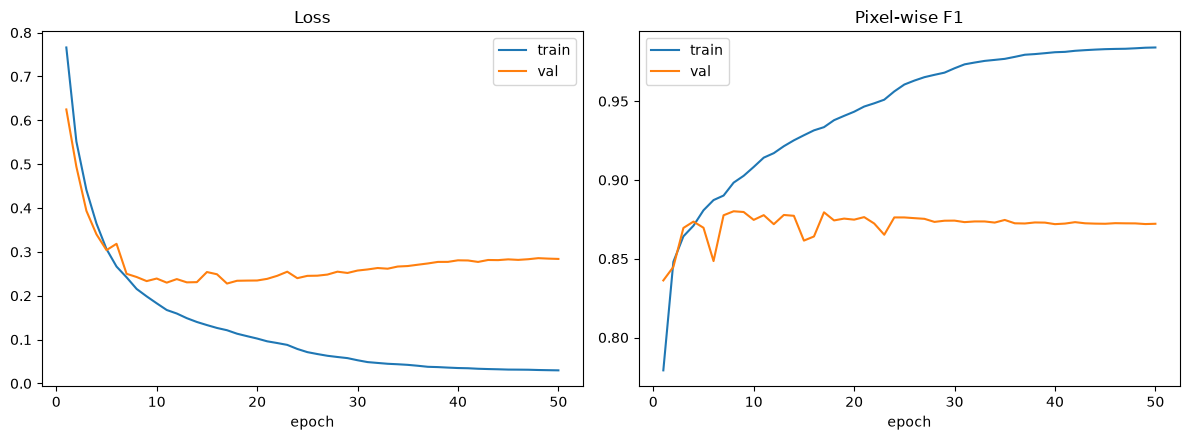

Saved training curves to /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/UNET/outputs/plots/training_curves.png


In [13]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

train_f1 = [m["f1"] for m in history["train_metrics"]]
val_f1 = [m["f1"] for m in history["val_metrics"]]
axes[1].plot(epochs_range, train_f1, label="train")
axes[1].plot(epochs_range, val_f1, label="val")
axes[1].set_title("Pixel-wise F1")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
curve_path = os.path.join(PLOTS_DIR, "training_curves.png")
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Saved training curves to {curve_path}")


## Final metrics: pixel + instance (mAP) for train / val / test

In [14]:
if os.path.isfile(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from {best_model_path} (epoch {checkpoint['epoch']})")

split_loaders = {"train": (train_loader, train_ids), "val": (val_loader, val_ids), "test": (test_loader, test_ids)}
summary_rows = []

for split_name, (loader, ids) in split_loaders.items():
    loss, pixel_metrics = run_epoch(loader, model, optimizer=None)
    inst_metrics = evaluate_instances(
        model, ids, images_by_id, annotations_by_image, IMAGES_DIR, IMG_SIZE, DEVICE,
        iou_thresholds=IOU_THRESHOLDS, prob_threshold=PROB_THRESHOLD, min_area=MIN_INSTANCE_AREA,
    )

    row = {
        "split": split_name,
        "loss": loss,
        "pixel_accuracy": pixel_metrics["accuracy"],
        "pixel_precision": pixel_metrics["precision"],
        "pixel_recall": pixel_metrics["recall"],
        "pixel_f1": pixel_metrics["f1"],
        "pixel_dice": pixel_metrics["dice"],
        "pixel_iou": pixel_metrics["iou"],
        "instance_precision": inst_metrics.get("instance_precision", float("nan")),
        "instance_recall": inst_metrics.get("instance_recall", float("nan")),
        "instance_f1": inst_metrics.get("instance_f1", float("nan")),
        "map_50": inst_metrics.get("map_50", float("nan")),
        "map_95": inst_metrics.get("map_95", float("nan")),
        "num_gt_instances": inst_metrics["num_gt_instances"],
        "num_predicted_instances": inst_metrics["num_predicted_instances"],
    }
    summary_rows.append(row)

    print(f"\n===== {split_name.upper()} =====")
    print(f"loss={loss:.4f}")
    print(f"Pixel    -> acc={row['pixel_accuracy']:.4f} prec={row['pixel_precision']:.4f} "
          f"recall={row['pixel_recall']:.4f} f1={row['pixel_f1']:.4f}")
    print(f"Instance -> prec={row['instance_precision']:.4f} recall={row['instance_recall']:.4f} "
          f"f1={row['instance_f1']:.4f}")
    print(f"mAP@50={row['map_50']:.4f}  mAP@95={row['map_95']:.4f}")

summary_path = os.path.join(METRICS_DIR, "metrics_summary_train_val_test.csv")
fieldnames = list(summary_rows[0].keys())
with open(summary_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(summary_rows)

print(f"\nSaved full train/val/test metric summary to {summary_path}")


Loaded best model from /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/UNET/outputs/models/unet_best.pth (epoch 17)


/tmp/ipykernel_152817/1982601191.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=DEVICE)



===== TRAIN =====
loss=0.1176
Pixel    -> acc=0.9873 prec=0.9278 recall=0.9440 f1=0.9357
Instance -> prec=0.8795 recall=0.8449 f1=0.8618
mAP@50=0.8030  mAP@95=0.0001

===== VAL =====
loss=0.2278
Pixel    -> acc=0.9752 prec=0.8740 recall=0.8852 f1=0.8795
Instance -> prec=0.6953 recall=0.7278 f1=0.7112
mAP@50=0.6168  mAP@95=0.0001

===== TEST =====
loss=0.2351
Pixel    -> acc=0.9751 prec=0.8707 recall=0.8789 f1=0.8747
Instance -> prec=0.6709 recall=0.7432 f1=0.7052
mAP@50=0.6230  mAP@95=0.0000

Saved full train/val/test metric summary to /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/UNET/outputs/metrics/metrics_summary_train_val_test.csv


## Save final model

In [15]:
final_model_path = os.path.join(MODEL_SAVE_DIR, "unet_final.pth")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to {final_model_path}")


Final model saved to /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/UNET/outputs/models/unet_final.pth


## Sample prediction visualizations (saved to outputs/predictions)

In [16]:
def save_prediction_examples(model, image_ids, images_by_id, annotations_by_image, images_dir,
                              img_size, device, out_dir, num_examples=6):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()
    img_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    sample_ids = image_ids[:num_examples]
    with torch.no_grad():
        for image_id in sample_ids:
            entry = images_by_id[image_id]
            anns = annotations_by_image.get(image_id, [])
            image = Image.open(os.path.join(images_dir, entry["file_name"])).convert("RGB")
            image_t = img_transform(image).unsqueeze(0).to(device)
            logits = model(image_t)
            pred = torch.argmax(logits, dim=1)[0].cpu().numpy()

            gt_mask = semantic_mask_for_image(entry, anns)
            gt_mask = np.array(Image.fromarray(gt_mask * 255).resize((img_size, img_size), Image.NEAREST)) > 127

            input_disp = np.array(image.resize((img_size, img_size)))
            fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
            axes[0].imshow(input_disp); axes[0].set_title("Input"); axes[0].axis("off")
            axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("Ground truth"); axes[1].axis("off")
            axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Prediction"); axes[2].axis("off")
            plt.tight_layout()
            out_path = os.path.join(out_dir, f"{entry['file_name'].rsplit('.', 1)[0]}_comparison.png")
            plt.savefig(out_path, dpi=130)
            plt.close(fig)

save_prediction_examples(model, test_ids, images_by_id, annotations_by_image, IMAGES_DIR,
                          IMG_SIZE, DEVICE, PREDICTIONS_DIR, num_examples=6)
print(f"Saved sample prediction comparisons to {PREDICTIONS_DIR}")


Saved sample prediction comparisons to /mnt/New_Volume/Projects/Solar Detection/Segmentation with Annotation/UNET/outputs/predictions
